# Analiza Online Prodavnice
## Vizualizacija raspodjele i korelacije
Cilj ove analize je da pretvorim sirove podatke u uvide koji ce pomoci timovima da razumiju sta se desava u prodaji.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('task03_data.csv')
df.head()

,product_name,category,price,quantity_in_stock,quantity_sold,brand,rating,num_of_ratings,date_added,color,revenue
0,"iPad mini (2021) (64GB, Blue)",Tablets,499.00,266.0,807.0,Apple,8.75,151.0,2/2/2022,blue,402693.00
1,K55 RGB (Red),Keyboards,49.99,0.0,1117.0,Corsair,8.50,455.0,8/14/2022,red,55838.83
2,Fenix 7 (Purple),Watches,699.99,0.0,530.0,Garmin,9.20,305.0,4/20/2022,purple,370994.70
3,"Mate 40 (256GB, Orange)",Smartphones,899.00,182.0,1030.0,Huawei,8.50,500.0,10/23/2024,orange,925970.00
4,Rival 600 (Red),Mice,79.99,35.0,1439.0,SteelSeries,9.25,556.0,9/29/2020,red,115105.61


In [5]:
print("Broj redova i kolona:",df.shape)
print("\nTipovi kolona:")
print(df.dtypes)
print("\nNedostajuce vrijednosti po koloni:")
print(df.isnull().sum())
df.describe()

Broj redova i kolona: (2935, 11)

Tipovi kolona:
product_name             str
category                 str
price                float64
quantity_in_stock    float64
quantity_sold        float64
brand                    str
rating               float64
num_of_ratings       float64
date_added               str
color                    str
revenue              float64
dtype: object

Nedostajuce vrijednosti po koloni:
product_name          0
category              0
price                 0
quantity_in_stock    41
quantity_sold         0
brand                 0
rating                0
num_of_ratings        0
date_added            0
color                 0
revenue               0
dtype: int64


,price,quantity_in_stock,quantity_sold,rating,num_of_ratings,revenue
count,2935.000000,2894.000000,2935.000000,2935.000000,2935.000000,2.935000e+03
mean,417.939366,163.610919,1041.228620,8.598075,403.995911,3.902837e+05
std,570.073771,166.610428,339.842234,0.391486,235.845642,4.842551e+05
min,6.000000,0.000000,0.000000,5.500000,0.000000,0.000000e+00
25%,90.000000,0.000000,793.000000,8.500000,203.000000,9.057175e+04
50%,199.000000,119.000000,1031.000000,8.700000,406.000000,1.925000e+05
75%,499.000000,310.750000,1272.000000,8.750000,603.000000,4.976712e+05
max,8195.000000,500.000000,3596.000000,9.750000,2908.000000,3.868040e+06


## Istrazivanje skupa podataka
Dataset sadrzi proizvode sa 11 obiljezija kao sto su:naziv,kategorija,brend,cijena,zaliha,prodata kolicina...itd
Kolone koje cu koristiti u analizi su:
quantity sold,
price,
rating,
num_of_ratings,
quantitiy_in_stock,
revenue

In [6]:
df_clean = df.dropna(subset=["quantity_sold","price","rating"])
print("Broj redova nakon ciscenja:",len(df_clean))

Broj redova nakon ciscenja: 2935


## Distribucija broja prodatih jedinica
Sada cu pokazati kako su proizvodi rasporedjeni,da li je prodaja ravnomjerna ili postoje ekstremi.

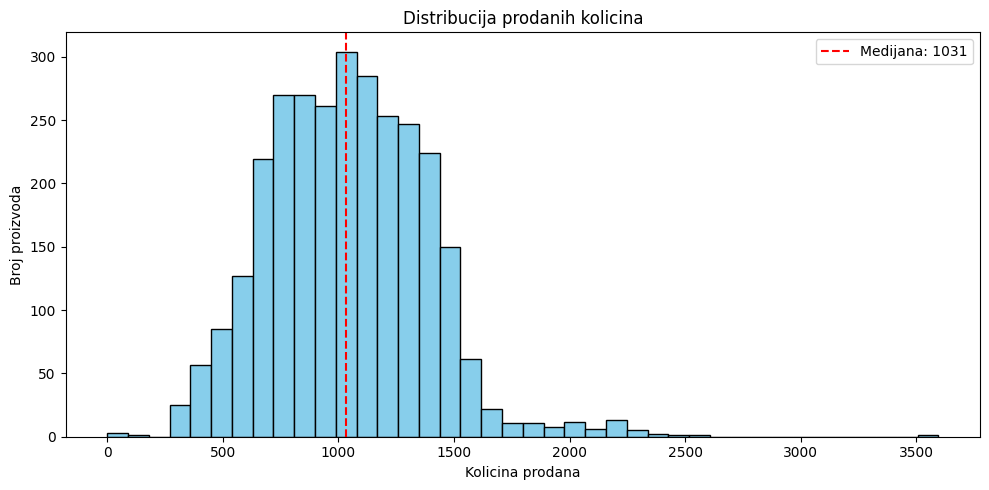

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df_clean['quantity_sold'], bins=40, color='skyblue', edgecolor='black')
medijana = df_clean['quantity_sold'].median()
plt.axvline(medijana, color='red', linestyle='--',label=f'Medijana: {medijana:.0f}')
plt.title('Distribucija prodanih kolicina')
plt.xlabel('Kolicina prodana')
plt.ylabel('Broj proizvoda')
plt.legend()
plt.tight_layout()
plt.show()

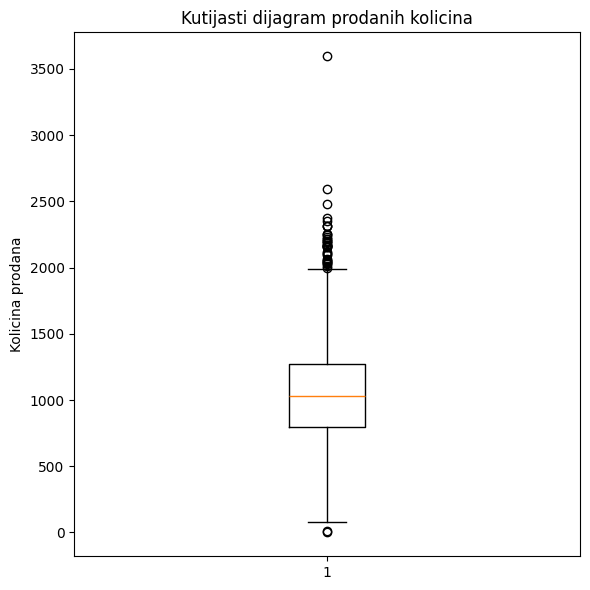

In [9]:
plt.figure(figsize=(6,6))
plt.boxplot(df_clean['quantity_sold'])
plt.title('Kutijasti dijagram prodanih kolicina')
plt.ylabel('Kolicina prodana')
plt.tight_layout()
plt.show()

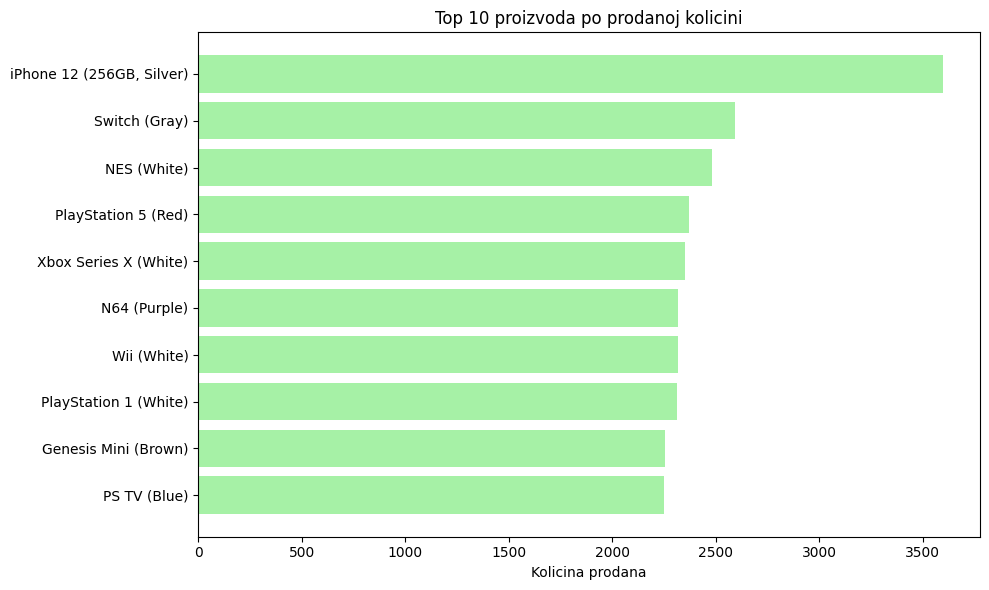

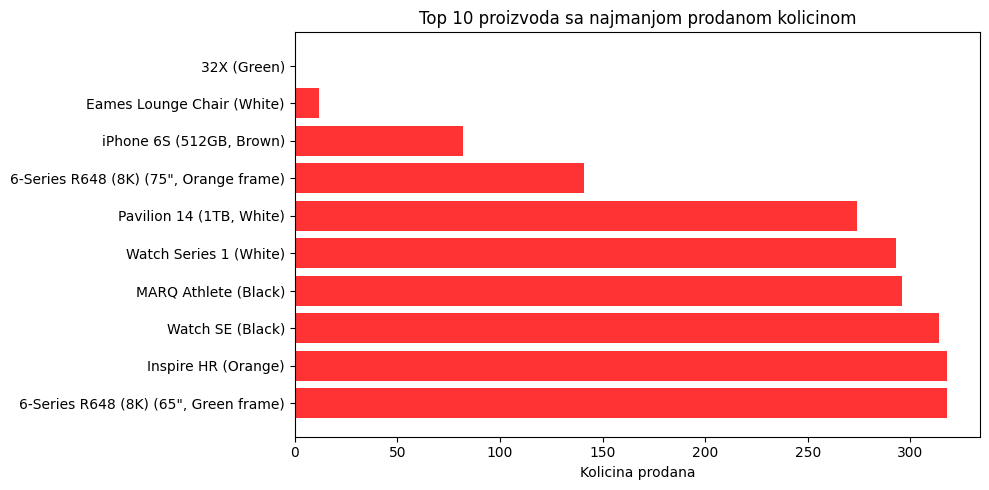

In [10]:
top10 =df_clean.nlargest(10, 'quantity_sold')[["product_name","quantity_sold"]]
plt.figure(figsize=(10,6))
plt.barh(top10["product_name"], top10["quantity_sold"], color='lightgreen',alpha=0.8)
plt.title('Top 10 proizvoda po prodanoj kolicini')
plt.xlabel('Kolicina prodana')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

bot10 = df_clean.nsmallest(10, 'quantity_sold')[["product_name","quantity_sold"]]
plt.figure(figsize=(10,5))
plt.barh(bot10["product_name"], bot10["quantity_sold"], color='red',alpha=0.8)
plt.title('Top 10 proizvoda sa najmanjom prodanom kolicinom')
plt.xlabel('Kolicina prodana')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Performanse po kategorijama
Pokazat cu koje kategorije generisu najvecu prodaju i da li su razlike izmedju kategorija velike ili male

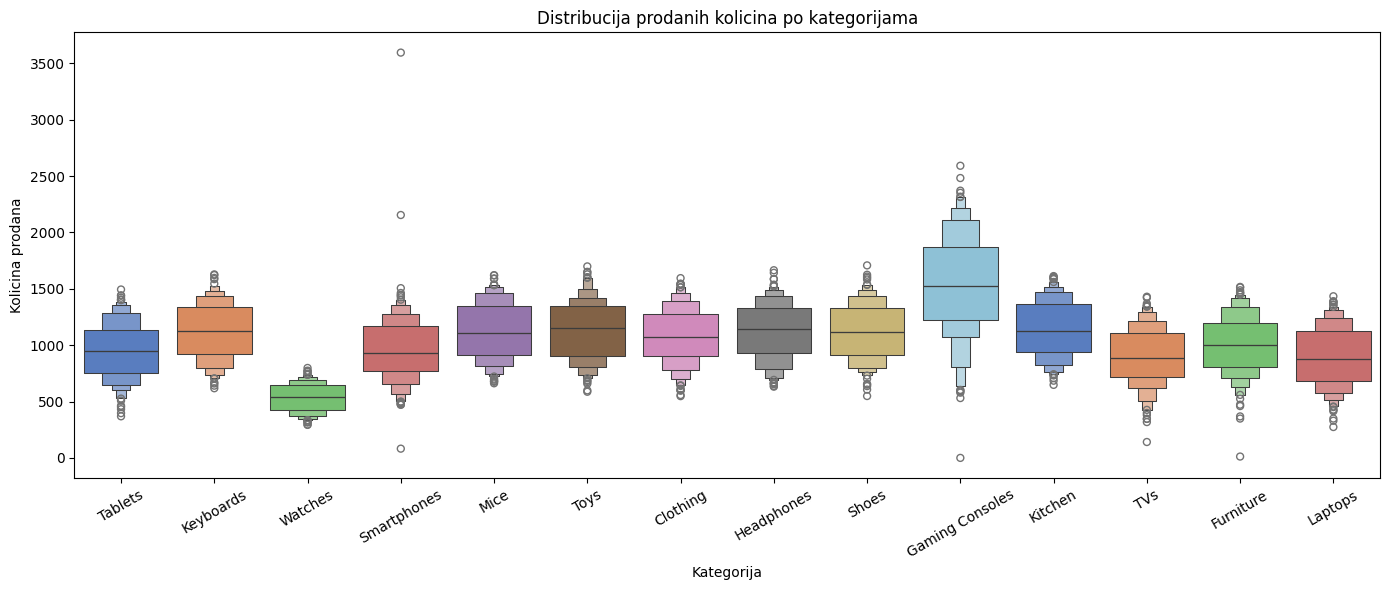

In [12]:
plt.figure(figsize=(14,6))
sns.boxenplot(data=df_clean, x='category', y='quantity_sold', hue='category', palette='muted',legend=False)
plt.title('Distribucija prodanih kolicina po kategorijama')
plt.xlabel('Kategorija')
plt.ylabel('Kolicina prodana')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

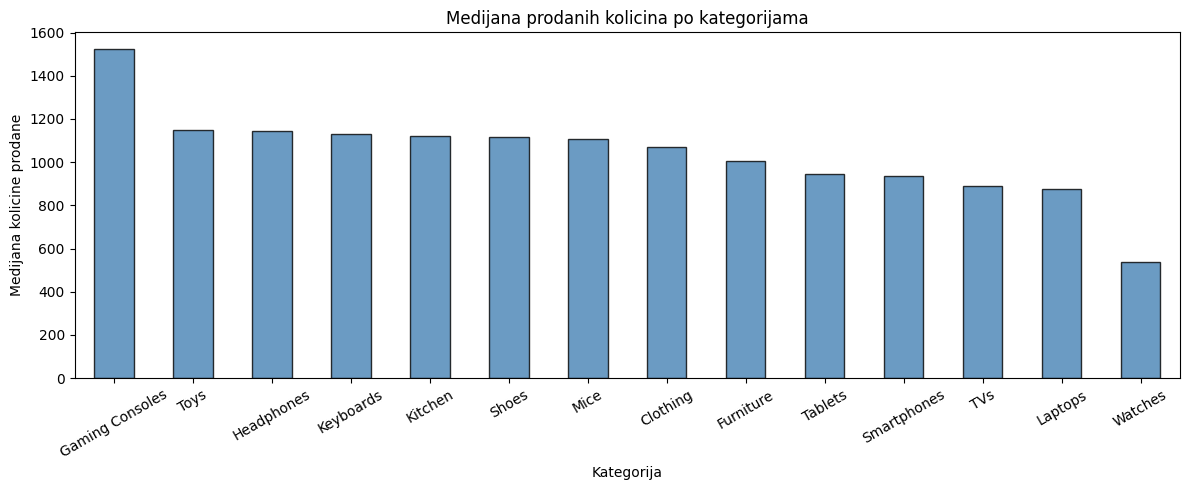

In [13]:
prodaja_po_kategoriji = df_clean.groupby('category')['quantity_sold'].median().sort_values(ascending=False)
plt.figure(figsize=(12,5))
prodaja_po_kategoriji.plot(kind='bar', color='steelblue',edgecolor='black', alpha=0.8)

plt.title('Medijana prodanih kolicina po kategorijama')
plt.xlabel('Kategorija')
plt.ylabel('Medijana kolicine prodane')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Korelaciona analiza
Koje numericke karakteristike su najvise povezane sa prodajom,vrijednosti blizu 1 ili -1 oznacavaju jaku vezu,blizu 0 slabu vezu.

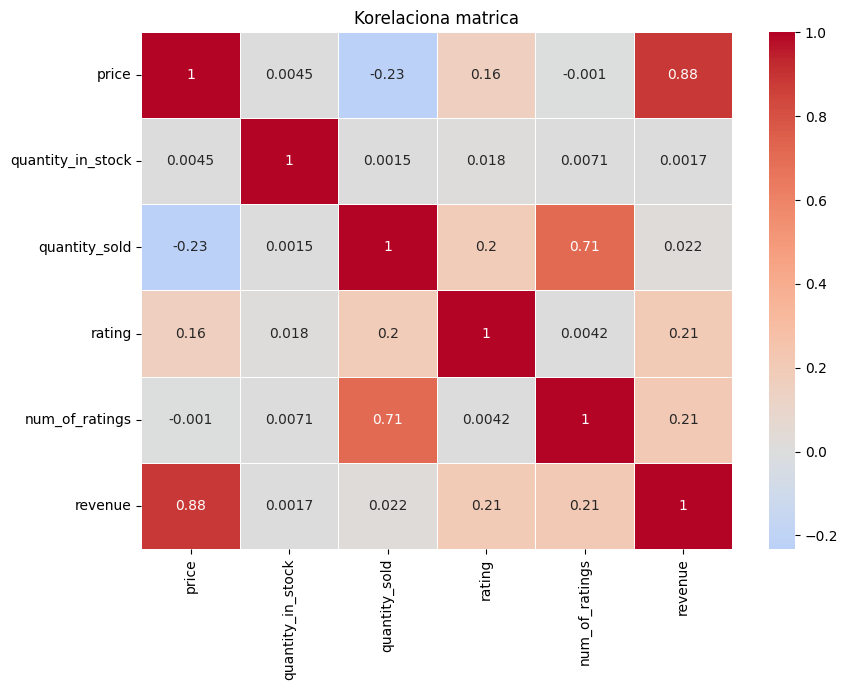

In [14]:
numericke_kolone = ['price','quantity_in_stock','quantity_sold','rating','num_of_ratings','revenue']
korelacija = df_clean[numericke_kolone].corr()
plt.figure(figsize=(9,7))
sns.heatmap(korelacija, annot=True, cmap='coolwarm', center=0,linewidths=0.5)
plt.title('Korelaciona matrica')
plt.tight_layout()
plt.show()

## Analiza kljucnih faktora uspjeha
Pokazat cu kako cijena i ocjena korisnika uticu na prodaju.

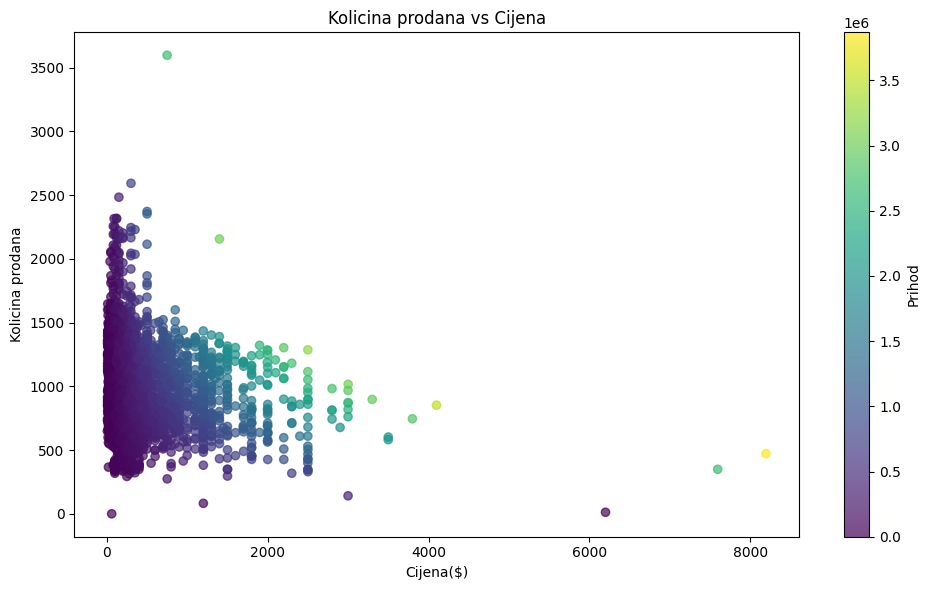

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(df_clean['price'], df_clean['quantity_sold'],c=df_clean['revenue'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Prihod')
plt.title('Kolicina prodana vs Cijena')
plt.xlabel('Cijena($)')
plt.ylabel('Kolicina prodana')
plt.tight_layout()
plt.show()

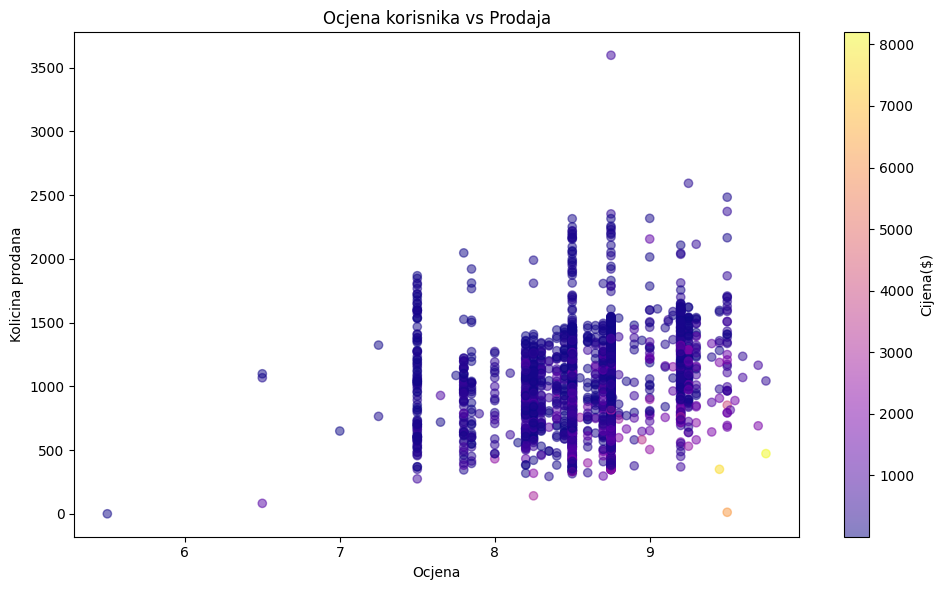

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(df_clean['rating'], df_clean['quantity_sold'],c=df_clean['price'], cmap='plasma', alpha=0.5)
plt.colorbar(label='Cijena($)')
plt.title('Ocjena korisnika vs Prodaja')
plt.xlabel('Ocjena')
plt.ylabel('Kolicina prodana')
plt.tight_layout()
plt.show()

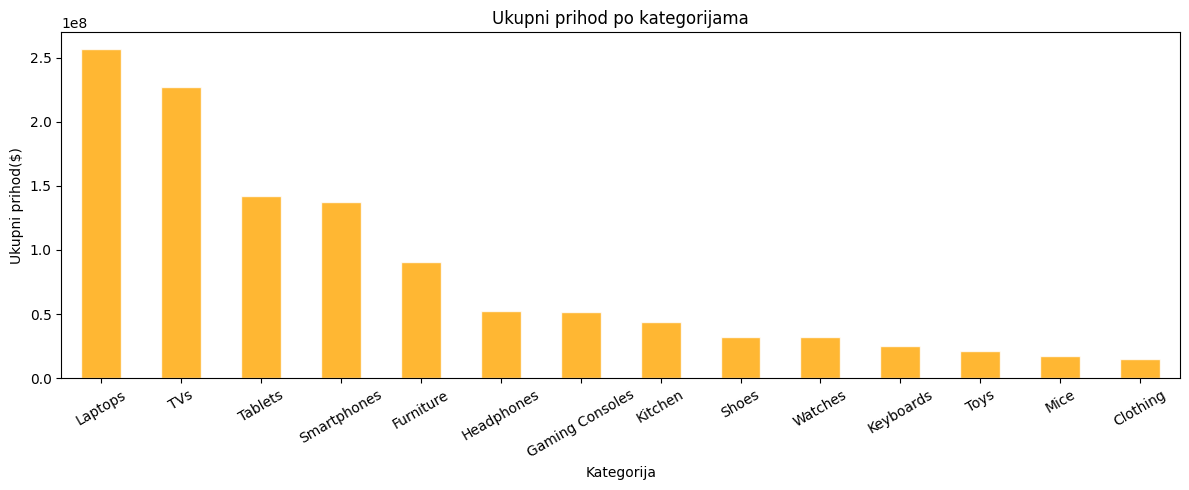

In [17]:
prihod_po_kategoriji = df_clean.groupby('category')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,5))
prihod_po_kategoriji.plot(kind='bar', color='orange',edgecolor='white', alpha=0.8)
plt.title('Ukupni prihod po kategorijama')
plt.xlabel('Kategorija')
plt.ylabel('Ukupni prihod($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Poslovni zakljucak
### Kljucni faktori uspjeha
Ocjena korisnika pozitivno korelira sa prodajom,bolje ocjenjeni proizvodi se vise prodaju.Broj ocjena prati prodaju,popularniji proizvodi imaju vise recenzija,sto provlaci nove kupce.
### PErformanse kategorija
Neke kategorije se jasno izdvajaju po medijani prodatih jedinica,kategorije sa velikim rasponom imaju i hitove i slabe proizvode unutar sebe.
### Obrasci koje treba pratiti
Postoje proizvodi sa nultim zalihama,ali visokom prodajom,distribucija prodaje je desno asimetricna,mali broj proizvoda ima neproporcionalno veliku prodaju.
### Preporuka za tim
Trebaju se fokusirati na dobro ocjenjene proizvode,jer ocjena direktrno korelira sa prodajom,proizvode sa nultom zalihom i velikom potraznjom hitno restockovati,kategorijama sa visokim prihodom dodijeliti veci marketniski budzet.
